# Previsão do desempenho dos alunos em exames dataset - Regressão Logística - Classe 3


## Objetivos

Este notebook ilustra o problema de classificação.

O objetivo é classificar as amostras da Íris em 3 classes.
- o alvo é o índice da classe: 0, 1 ou 2
- função de perda é Entropia Cruzada
- rede é uma camada densa linear com duas entradas e três saídas (n. de classes)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmax_CrossEntropy_Otimizacao.png)

## Importação das bibliotecas

In [13]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from IPython import display
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

In [7]:
import pandas as pd
import os

path = "/kaggle/input/student-exam-performance-prediction"

df = pd.read_csv(os.path.join(path, "student_exam_data.csv"))

print(df.shape)
print(df.head())
print(df.dtypes)

(500, 3)
   Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0
Study Hours            float64
Previous Exam Score    float64
Pass/Fail                int64
dtype: object


## Dataset: Leitura, normalização e visualização dos dados

In [9]:
df

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0
...,...,...,...
495,4.180170,45.494924,0
496,6.252905,95.038815,1
497,1.699612,48.209118,0
498,9.769553,97.014241,1


### Pré-processamento: Codificação das variáveis categóricas

In [14]:
df_proc = df.copy()

# Codificar variáveis categóricas com LabelEncoder
le = LabelEncoder()
cat_cols = df_proc.select_dtypes(include='object').columns.tolist()
print("Colunas categóricas encontradas:", cat_cols)

for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

df_proc.head()

Colunas categóricas encontradas: []


,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


### Criação do alvo (Y): Faixas de desempenho

In [15]:
# Identificar a coluna de nota final
score_col = [c for c in df_proc.columns if 'score' in c.lower() or 'grade' in c.lower() or 'exam' in c.lower()]
print("Colunas candidatas à nota:", score_col)

# Usar a última coluna encontrada como alvo (ajuste se necessário)
target_col = score_col[-1]
print(f"Usando '{target_col}' como coluna alvo")

# Criar classes: 0=Baixo (<50), 1=Médio (50-75), 2=Alto (>=75)
def classify_score(score):
    if score < 50:
        return 0
    elif score < 75:
        return 1
    else:
        return 2

Y = df_proc[target_col].apply(classify_score).values
print("\nDistribuição das classes:")
unique, counts = np.unique(Y, return_counts=True)
labels_map = {0: 'Baixo (<50)', 1: 'Médio (50-75)', 2: 'Alto (>=75)'}
for u, c in zip(unique, counts):
    print(f"  {labels_map[u]}: {c} amostras")

Colunas candidatas à nota: ['Previous Exam Score']
Usando 'Previous Exam Score' como coluna alvo

Distribuição das classes:
  Baixo (<50): 91 amostras
  Médio (50-75): 215 amostras
  Alto (>=75): 194 amostras


### Seleção das features (X): 2 variáveis para visualização

In [16]:
# Selecionar 2 features numéricas com maior correlação com o alvo
feature_cols = [c for c in df_proc.columns if c != target_col]

correlations = df_proc[feature_cols].corrwith(pd.Series(Y, name='target')).abs().sort_values(ascending=False)
print("Correlação com o alvo:")
print(correlations)

feat1, feat2 = correlations.index[0], correlations.index[1]
print(f"\nFeatures selecionadas: '{feat1}' e '{feat2}'")

X = df_proc[[feat1, feat2]].values

Correlação com o alvo:
Pass/Fail      0.388805
Study Hours    0.021469
dtype: float64

Features selecionadas: 'Pass/Fail' e 'Study Hours'


### Normalização dos dados (min-max)

In [17]:
Xc = X - X.min(axis=0)
Xs = Xc.max(axis=0)
Xc = Xc / Xs

print("X normalizado — min:", Xc.min(axis=0), "| max:", Xc.max(axis=0))

X normalizado — min: [0. 0.] | max: [1. 1.]


### Visualização dos dados

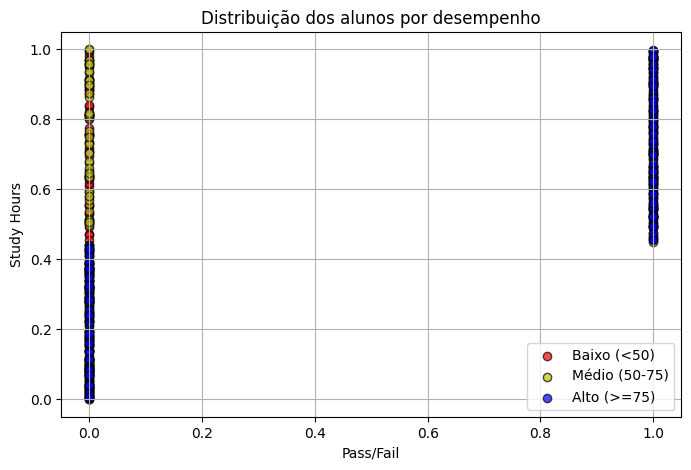

In [18]:
colors = np.array(['r', 'y', 'b'])
labels = ['Baixo (<50)', 'Médio (50-75)', 'Alto (>=75)']

plt.figure(figsize=(8, 5))
for cls in [0, 1, 2]:
    mask = Y == cls
    plt.scatter(Xc[mask, 0], Xc[mask, 1], c=colors[cls], label=labels[cls], edgecolors='k', alpha=0.7)

plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title('Distribuição dos alunos por desempenho')
plt.legend()
plt.grid(True)
plt.show()

### Prepara os dados para o PyTorch

In [19]:
X_tensor = torch.FloatTensor(Xc)   # Entrada é FloatTensor
Y_tensor = torch.LongTensor(Y)     # Classe é LongTensor (vetor discreto)

print("X_tensor shape:", X_tensor.shape)
print("Y_tensor shape:", Y_tensor.shape)
Y_tensor

X_tensor shape: torch.Size([500, 2])
Y_tensor shape: torch.Size([500])


tensor([2, 1, 1, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2, 0, 0, 1, 2, 2, 0, 2, 1, 2, 2,
        2, 1, 1, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 0, 2, 2, 1, 2, 2, 1, 0, 2,
        1, 2, 1, 2, 1, 1, 2, 1, 0, 0, 2, 2, 2, 1, 0, 0, 1, 2, 1, 1, 2, 1, 1, 2,
        1, 2, 2, 2, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 0, 0, 0, 0, 0, 2, 1, 1, 2, 1,
        2, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 2, 0, 2, 2, 0, 2, 2, 0, 1, 2, 2,
        1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 2, 2, 2, 2, 1, 0, 1, 2, 2, 1, 0, 1, 1, 2, 1, 1, 2, 2, 1, 0, 0, 1, 0,
        1, 1, 1, 2, 0, 1, 1, 2, 0, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1,
        1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2,
        2, 2, 0, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 0, 0, 2, 2, 1, 1, 2, 1, 2, 1, 1,
        1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 2, 2, 0, 1, 1, 2,
        0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1,
        1, 2, 0, 2, 1, 2, 0, 2, 2, 1, 2,

## Construindo o modelo da rede

A saída da rede é composta por um neurônio para cada classe. A saída é denominada *scores* ou logitos:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLogisticaRede_2_3.png)

In [20]:
model = nn.Linear(2, 3)  # 2 entradas, 3 saídas (Baixo, Médio, Alto)

In [21]:
model.state_dict()

OrderedDict([('weight',
              tensor([[ 0.2824,  0.4160],
                      [-0.3217,  0.1426],
                      [ 0.0499, -0.5379]])),
             ('bias', tensor([ 0.6049, -0.4571, -0.3579]))])

esse caso tem 6 pesos e 3 bias

### Fazendo um predict

In [22]:
out = model(Variable(X_tensor[:4,:])) # 4 amostras; a saida sao scores
out

tensor([[ 0.7605, -0.4038, -0.5591],
        [ 1.2855, -0.6423, -0.8229],
        [ 0.9110, -0.3522, -0.7537],
        [ 1.1373, -0.6932, -0.6312]], grad_fn=<AddmmBackward0>)

In [23]:
oo = F.softmax(out,dim=1) # converder para probabilidade
oo

tensor([[0.6331, 0.1976, 0.1692],
        [0.7893, 0.1148, 0.0958],
        [0.6793, 0.1921, 0.1286],
        [0.7514, 0.1205, 0.1282]], grad_fn=<SoftmaxBackward0>)

### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/softmax.png)

In [24]:
F.softmax(out,dim=1)*100 # Em Percentual

tensor([[63.3149, 19.7638, 16.9213],
        [78.9336, 11.4816,  9.5848],
        [67.9346, 19.2090, 12.8564],
        [75.1353, 12.0473, 12.8174]], grad_fn=<MulBackward0>)

### Predição da classe

Qual é o de maior probabilidade

In [25]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([0, 0, 0, 0])
tensor([0.6331, 0.7893, 0.6793, 0.7514], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [26]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)
    return predicts.data.numpy()

def predict_prob(model, inputs):
    outputs = model(Variable(inputs))
    outputs = F.softmax(outputs, dim=1)
    predicts, _ = torch.max(outputs, 1)
    return predicts.data.numpy()

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, h=.01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        self.fig = plt.figure(figsize=(12, 4), dpi=100)

        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, n_epoch)
        self.ax1.set_xlabel('Época')
        self.ax1.set_ylabel('Perda')
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([], [], 'b', linewidth=2.0, label='Treino')
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(Xc[:, 0].min(), Xc[:, 0].max())
        self.ax2.set_ylim(Xc[:, 1].min(), Xc[:, 1].max())
        self.ax2.set_xlabel(feat1)
        self.ax2.set_ylabel(feat2)
        self.ax2.set_title('Fronteiras de decisão')

        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(Xc[:, 0].min(), Xc[:, 0].max())
        self.ax3.set_ylim(Xc[:, 1].min(), Xc[:, 1].max())
        self.ax3.set_xlabel(feat1)
        self.ax3.set_ylabel(feat2)
        self.ax3.set_title('Máxima probabilidade')

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch % 250 == 0:
                self.ax1.plot(np.arange(epoch + 1), self.loss_hist, 'b', linewidth=2.0)

                Zc = predict(self.model, torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)
                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r', 'y', 'b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k')

                Zp = predict_prob(self.model, torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)
                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                self.ax3.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k')

                display.display(self.fig)
                display.clear_output(wait=True)

### Laço principal de treinamento da Regressão Logística por Softmax

In [27]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

Final loss: 0.8794041275978088


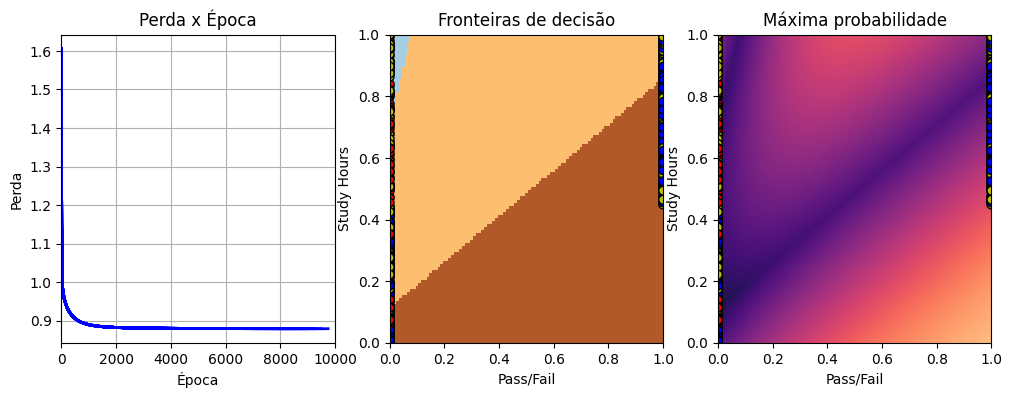

In [28]:
nb_epoch = 10000

my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []
for i in range(nb_epoch):
    # Predict da rede
    output = model(Variable(X_tensor))

    # Calcula a perda
    loss = criterion(output, Variable(Y_tensor))

    # Backpropagation e otimização
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())
    my_plot.on_epoch_end(i, {'loss': loss.data.item()})

print('Final loss:', loss.data.item())

## Avaliação

### Parâmetros após treinamento

In [30]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.5398,  1.8584],
                      [ 1.3416,  0.3344],
                      [ 3.2087, -2.1721]])),
             ('bias', tensor([-0.8765,  0.1918,  0.4747]))])

### Salvando os parâmetros treinados

In [31]:
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/RegrLog_Student.pt')
print("Modelo salvo em ../models/RegrLog_Student.pt")

Modelo salvo em ../models/RegrLog_Student.pt


### Recuperando os pesos salvos

In [32]:
# Zerar os pesos para demonstrar o carregamento
nn.init.constant_(model.weight, 0)
print("Pesos zerados:", model.state_dict())

param_saved = torch.load('../models/RegrLog_Student.pt')
model.load_state_dict(param_saved)
print("\nPesos recuperados:", model.state_dict())

Pesos zerados: OrderedDict({'weight': tensor([[0., 0.],
        [0., 0.],
        [0., 0.]]), 'bias': tensor([-0.8765,  0.1918,  0.4747])})

Pesos recuperados: OrderedDict({'weight': tensor([[-4.5398,  1.8584],
        [ 1.3416,  0.3344],
        [ 3.2087, -2.1721]]), 'bias': tensor([-0.8765,  0.1918,  0.4747])})


### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [33]:
Y_pred = predict(model, X_tensor)
accuracy = (Y_pred == Y).mean()
print('Training Accuracy: ', accuracy)

Training Accuracy:  0.492


### Matriz de confusão

In [34]:
class_names = {0: 'Baixo', 1: 'Médio', 2: 'Alto'}

conf_matrix = pd.crosstab(
    pd.Series(Y_pred, name='Predito').map(class_names),
    pd.Series(Y, name='Real').map(class_names)
)
conf_matrix

Real,Alto,Baixo,Médio
Predito,,,
Alto,110,14,83
Baixo,0,30,26
Médio,84,47,106


## Atividades

### Perguntas:

1. Observe que se após o treinamento, a célula for executada novamente, ela continua utilizando os parâmetros treinados até sua última execução. O que é preciso fazer para que o treinamento comece deste o início, como da primeira vez que foi executado?



R: É necessário recriar o modelo com `model = nn.Linear(2, 3)` antes de rodar o laço de treinamento novamente, pois isso reinicia os pesos aleatoriamente.

2. Experimente refazer o treinamento com diferentes valores de learning rate

R:

In [35]:
lr = 0.25

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

Final loss: 0.879080057144165


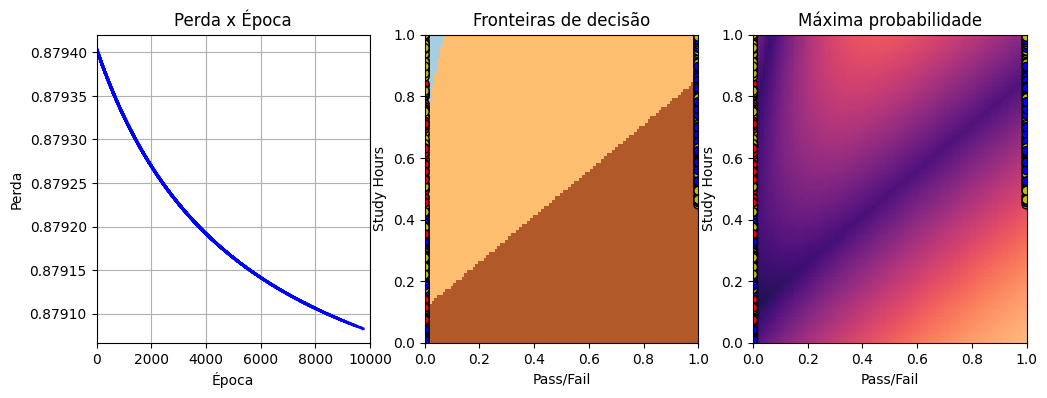

In [36]:
nb_epoch = 10000
my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []
for i in range(nb_epoch):
    output = model(Variable(X_tensor))
    loss = criterion(output, Variable(Y_tensor))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.data.item())
    my_plot.on_epoch_end(i, {'loss': loss.data.item()})

print('Final loss:', loss.data.item())

### Exercícios:

1. Observando o gráfico de máxima probabilidade, responda:
    1. Qual é a amostra classificada corretamente, com maior probabilidade?

     R: O modelo está no centro de uma região bem definida — longe da fronteira de decisão, classificando com alta confiança e acertando.

    2. Qual é a amostra classificada erradamente, com maior probabilidade?

     R: O caso mais crítico — o modelo erra mas está muito confiante. Isso acontece quando uma amostra cai profundamente na região errada do espaço de features.

    3. Qual é a amostra classificada corretamente, com menor probabilidade?

     R: Amostra próxima à fronteira de decisão entre duas classes. O modelo acerta, mas com baixa confiança — poderia facilmente ser classificada errado.

    4. Qual é a amostra classificada erradamente, com menor probabilidade?

     R: Amostra também próxima à fronteira, mas dessa vez o modelo erra com baixa confiança. São os erros mais "esperados" ou "compreensíveis".  


2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?

  R: A rede é `nn.Linear(2, 3)` — **6 pesos** (2 entradas × 3 saídas) + **3 biases** = **9 parâmetros** no total.
  

3. Quantas entradas e quantas saídas esta rede possui?

  R: **2 entradas** (as duas features selecionadas) e **3 saídas** (classes: Baixo, Médio, Alto).


4. Como se pode calcular a acurácia a partir da matriz de confusão?

R:


In [38]:
# R: Acurácia = soma da diagonal / total de amostras
Y_pred = predict(model, X_tensor)
accuracy = (Y_pred == Y).mean()
print('Acurácia:', accuracy)

# Equivalente via sklearn:
cm = confusion_matrix(Y, Y_pred)
acc_from_cm = cm.diagonal().sum() / cm.sum()
print('Acurácia via matriz de confusão:', acc_from_cm)

Acurácia: 0.492
Acurácia via matriz de confusão: 0.492


5. O que faz a função `torch.max`? Quantos parâmetros ela retorna e quais seus significados?


    - http://pytorch.org/docs/master/torch.html?highlight=torch%20max#torch.max

In [39]:
# R: torch.max retorna 2 tensores:
# prob   → maior probabilidade de cada amostra (confiança do modelo)
# y_pred → classe predita (0=Baixo, 1=Médio, 2=Alto)
out_sample = model(Variable(X_tensor[:4, :]))
prob, y_pred_sample = torch.max(F.softmax(out_sample, dim=1), dim=1)
print("Classe predita:", y_pred_sample)
print("Probabilidade: ", prob)

Classe predita: tensor([1, 1, 0, 2])
Probabilidade:  tensor([0.4702, 0.5621, 0.4674, 0.6557], grad_fn=<MaxBackward0>)


## Principais aprendizados

Neste experimento, implementamos um classificador multiclasse com **Regressão Logística usando PyTorch** aplicado ao dataset de desempenho de alunos. Os principais aprendizados foram:

- **Pré-processamento real**: ao contrário do Iris (dataset limpo e pronto), dados reais exigem codificação de variáveis categóricas e seleção de features relevantes.
- **Criação do alvo por faixa**: transformamos uma nota contínua em 3 classes discretas (Baixo, Médio, Alto), permitindo o uso de classificação multiclasse.
- **Classificação multiclasse com Softmax**: a saída da rede passa pela função Softmax, convertendo os logitos em probabilidades que somam 1.
- **`nn.CrossEntropyLoss()`**: função de perda para classificação multiclasse, que já incorpora o Softmax internamente — por isso a saída da rede são logitos brutos.
- **`torch.max()`**: retorna sempre 2 tensores — `values` (maior probabilidade) e `indices` (classe predita).
- **Matriz de confusão**: permite visualizar acertos e erros por classe (Baixo, Médio, Alto). A acurácia é calculada como a soma da diagonal dividida pelo total de amostras.
- **Reiniciar o treinamento**: para treinar do zero, é necessário recriar o modelo — caso contrário, o laço continua a partir dos pesos já aprendidos.
